# Order Flow and Price Formation

If financial returns appear nearly random,
what actually drives price changes in markets?

Market microstructure theory provides a clear answer:

**Prices move because of trades.**

The sequence of buy and sell orders arriving to the market
is called **order flow**.

In this notebook we explore:

- how order flow generates price changes
- different models of order flow
- persistence in trading activity

## Import Simulation Components

Chúng ta sẽ sử dụng các module trong package simulation
để mô phỏng cơ chế hình thành giá.

Các thành phần chính gồm:

- limit order book
- liquidity model
- market maker
- order flow generator
- market simulation engine

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from src.structure import (
    OrderBook,
    LiquidityModel,
    MarketMaker,
    RandomOrderFlow,
    PersistentOrderFlow,
    MetaOrderFlow,
    MarketSimulation
)

from src.metrics import order_flow_autocorrelation

## Order Flow Definition

Order flow là chuỗi các lệnh thị trường (market orders)
được gửi vào thị trường theo thời gian.

Mỗi giao dịch có:

- **side** : buy hoặc sell
- **size** : khối lượng giao dịch

Ta định nghĩa **signed order flow**:

$$
q_t =
\begin{cases}
+V_t & \text{buy order} \\
-V_t & \text{sell order}
\end{cases}
$$

trong đó $V_t$ là khối lượng giao dịch.

Trong nhiều mô hình microstructure,
biến động giá liên hệ trực tiếp với order flow:

$$
\Delta P_t = \lambda q_t
$$

Trong đó:

- $\lambda$ : price impact coefficient
- $q_t$ : signed order flow

## Order Flow Definition

Order flow là chuỗi các lệnh thị trường (market orders)
được gửi vào thị trường theo thời gian.

Mỗi giao dịch có:

- **side** : buy hoặc sell
- **size** : khối lượng giao dịch

Ta định nghĩa **signed order flow**:

$$
q_t =
\begin{cases}
+V_t & \text{buy order} \\
-V_t & \text{sell order}
\end{cases}
$$

trong đó $V_t$ là khối lượng giao dịch.

Trong nhiều mô hình microstructure,
biến động giá liên hệ trực tiếp với order flow:

$$
\Delta P_t = \lambda q_t
$$

Trong đó:

- $\lambda$ : price impact coefficient
- $q_t$ : signed order flow

In [16]:
orderbook = OrderBook()

liquidity = LiquidityModel()

market_maker = MarketMaker()

order_flow = RandomOrderFlow()

sim = MarketSimulation(
    orderbook,
    liquidity,
    market_maker,
    order_flow,
)

In [17]:
result = sim.run(steps=5000)

prices = result["prices"]
trades = result["trades"]

len(trades)

5022

## Interpretation of Trade Count

Kết quả cho thấy:
$$number of trades = 5022$$

trong khi simulation được chạy với:
$$ steps = 5000 $$

Điều này xảy ra vì trong mỗi bước của simulation,
ngoài giao dịch chính từ **order flow**, có thể xuất hiện thêm
các giao dịch khác từ cơ chế thị trường.

### Sources of Trades

Trong simulation engine, mỗi bước bao gồm nhiều hoạt động:

1. market maker đặt bid/ask quotes
2. order flow sinh ra một market order
3. market order được thực thi trong order book
4. market maker cập nhật inventory

Trong một số trường hợp,
market maker có thể phải **giảm inventory**
để kiểm soát rủi ro.

Điều này dẫn tới các giao dịch bổ sung
ngoài giao dịch từ order flow.

### Implication

Vì vậy số lượng trades trong simulation
có thể **lớn hơn số bước thời gian**.

Điều này phản ánh một đặc điểm quan trọng
của thị trường thực:

mỗi sự kiện giao dịch có thể kích hoạt
các phản ứng tiếp theo từ các liquidity providers.

## Price Series Generated by Order Flow

Chuỗi giá được hình thành thông qua tương tác giữa:

- order flow
- liquidity trong order book
- market maker

Mỗi market order sẽ **consume liquidity**
từ limit order book.

Điều này làm thay đổi **mid price** của thị trường.

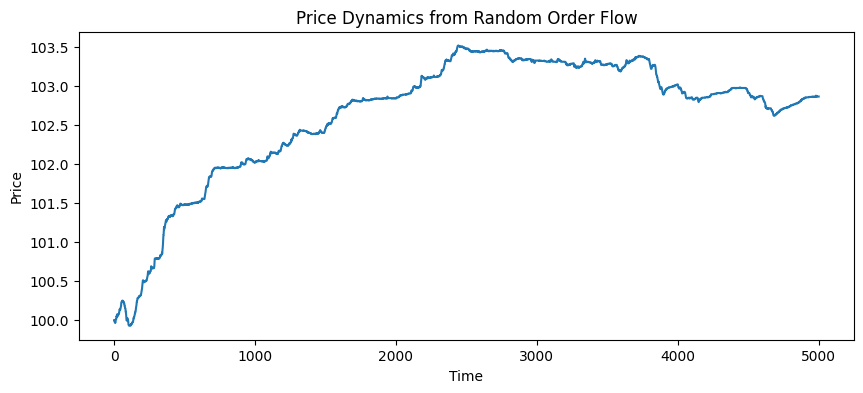

In [18]:
plt.figure(figsize=(10,4))
plt.plot(prices)
plt.title("Price Dynamics from Random Order Flow")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Interpretation of Price Dynamics

Biểu đồ trên thể hiện chuỗi giá được tạo ra bởi **random order flow**.

Trong simulation, mỗi bước thời gian:

1. một market order được sinh ra từ order flow
2. lệnh này được thực thi trong limit order book
3. liquidity trong order book bị tiêu thụ
4. mid price của thị trường thay đổi

Do đó biến động giá xuất hiện như một hệ quả trực tiếp của **giao dịch**.

### Observations

Từ biểu đồ có thể quan sát:

- Giá thay đổi theo từng bước nhỏ tương ứng với các giao dịch.
- Chuỗi giá có dạng **random walk**.
- Không có xu hướng rõ ràng trong dài hạn.

Điều này phản ánh đặc điểm của **random order flow**,
trong đó buy và sell xuất hiện ngẫu nhiên với xác suất gần bằng nhau.

### Microstructure Interpretation

Trong market microstructure, giá thay đổi khi liquidity trong order book bị tiêu thụ.

Ví dụ:

- market buy order → consume ask liquidity → giá tăng
- market sell order → consume bid liquidity → giá giảm

Do đó price dynamics có thể được mô tả bằng relation đơn giản:

$$
\Delta P_t = \lambda q_t
$$

trong đó:

- $q_t$ : signed order flow
- $\lambda$ : price impact coefficient

### Implication

Kết quả này cho thấy rằng **price changes được tạo ra bởi order flow**.

Nói cách khác:

> Prices move because of trades.

Trong các phần tiếp theo,
chúng ta sẽ nghiên cứu các dạng order flow phức tạp hơn,
bao gồm **persistent order flow** và **meta orders**.

## Trade Sign Series

Mỗi giao dịch có thể được biểu diễn bằng **trade sign**:

$$
s_t =
\begin{cases}
+1 & \text{buy order} \\
-1 & \text{sell order}
\end{cases}
$$

Chuỗi $s_t$ thể hiện **direction của order flow** theo thời gian.

Nếu order flow hoàn toàn ngẫu nhiên,
chuỗi này sẽ giống **white noise**.

Nếu tồn tại persistence,
ta sẽ thấy các đoạn dài cùng dấu:

buy → buy → buy
sell → sell → sell

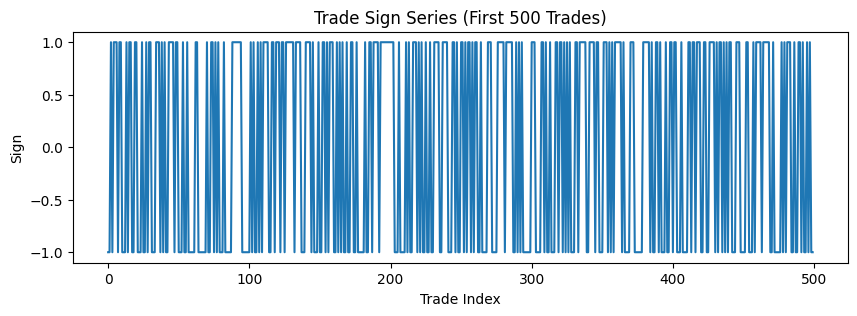

In [19]:
signs = []

for t in trades:
    if t["side"] == "buy":
        signs.append(1)
    else:
        signs.append(-1)

plt.figure(figsize=(10,3))
plt.plot(signs[:500])
plt.title("Trade Sign Series (First 500 Trades)")
plt.xlabel("Trade Index")
plt.ylabel("Sign")
plt.show()

## Interpretation of Trade Sign Series

Biểu đồ trên thể hiện **trade signs** của 500 giao dịch đầu tiên.

Mỗi giao dịch được mã hóa:

$$
s_t =
\begin{cases}
+1 & \text{buy trade} \\
-1 & \text{sell trade}
\end{cases}
$$

Chuỗi $s_t$ cho biết **direction của order flow theo thời gian**.

### Observations

Từ biểu đồ có thể quan sát:

- Trade signs thay đổi nhanh giữa +1 và −1.
- Không xuất hiện các đoạn dài cùng dấu.
- Chuỗi trông giống **white noise**.

Điều này cho thấy **buy và sell xảy ra gần như độc lập**.

### Interpretation

Trong simulation hiện tại,
order flow được sinh bởi mô hình **RandomOrderFlow**.

Mô hình này giả định:

- xác suất buy ≈ xác suất sell
- các giao dịch độc lập theo thời gian
- không có persistence trong trade direction

Do đó chuỗi trade signs không có cấu trúc rõ ràng.

### Implication

Trong dữ liệu thị trường thực,
trade signs thường **không hoàn toàn ngẫu nhiên**.

Ta thường quan sát các chuỗi dài cùng dấu:

buy → buy → buy → buy
sell → sell → sell → sell

Hiện tượng này gọi là **order flow persistence**.

Nguyên nhân chính là **meta-order splitting**,
khi các nhà đầu tư lớn chia nhỏ giao dịch lớn thành nhiều lệnh nhỏ.

Phần tiếp theo của notebook sẽ mô phỏng
**persistent order flow** để tái tạo hiện tượng này.

## Order Flow Persistence

Một stylized fact quan trọng của thị trường tài chính là:

**order flow signs có autocorrelation dương.**

Điều này nghĩa là:

buy orders có xu hướng được theo sau bởi buy orders,
sell orders có xu hướng được theo sau bởi sell orders.

Nguyên nhân chính là:

các nhà đầu tư lớn thường chia nhỏ giao dịch lớn
thành nhiều lệnh nhỏ (meta-orders).

In [5]:
order_flow_autocorrelation(trades)

np.float64(0.023313085010360966)

## Interpretation of Order Flow Autocorrelation

Để đo persistence trong order flow,
ta tính **autocorrelation của trade signs**.

Trade sign được định nghĩa:

$$
s_t =
\begin{cases}
+1 & \text{buy trade} \\
-1 & \text{sell trade}
\end{cases}
$$

Autocorrelation tại lag $k$:

$$
\rho_k =
\frac{E[(s_t - \mu)(s_{t-k} - \mu)]}{\sigma^2}
$$

trong đó $s_t$ là trade sign tại thời điểm $t$.

### Result

Kết quả từ simulation:
$$ order flow autocorrelation ≈ 0.023 $$


Giá trị này **rất gần 0**.

### Interpretation

Điều này cho thấy direction của giao dịch:

- buy hoặc sell
- gần như **độc lập theo thời gian**

Đặc điểm này phù hợp với mô hình **RandomOrderFlow**,
trong đó mỗi giao dịch được sinh ra ngẫu nhiên
với xác suất buy ≈ sell.

### Implication

Trong dữ liệu thị trường thực,
autocorrelation của trade signs thường **lớn hơn đáng kể**.

Ta thường quan sát:

$$
Corr(s_t, s_{t-k}) > 0
$$

trong nhiều lag.

Hiện tượng này gọi là **order flow persistence**,
và là một stylized fact quan trọng của thị trường tài chính.

Nguyên nhân chính là các **meta orders**,
khi nhà đầu tư lớn chia nhỏ giao dịch lớn
thành nhiều giao dịch nhỏ cùng direction.

Phần tiếp theo của notebook sẽ mô phỏng
persistent order flow để tái tạo hiện tượng này.

## Order Flow Autocorrelation Across Lags

Để hiểu rõ cấu trúc của order flow,
ta cần quan sát autocorrelation của trade signs
ở nhiều lag khác nhau.

Autocorrelation tại lag $k$:

$$
\rho_k =
Corr(s_t, s_{t-k})
$$

Nếu order flow hoàn toàn ngẫu nhiên,
ta kỳ vọng:

$$
\rho_k \approx 0
$$

đối với mọi $k$.

Trong dữ liệu thị trường thực,
autocorrelation của trade signs thường **giảm chậm theo lag**,
cho thấy **long memory in order flow**.

In [20]:
signs = []

for t in trades:
    if t["side"] == "buy":
        signs.append(1)
    else:
        signs.append(-1)

signs = np.array(signs)

max_lag = 50
autocorr = []

for lag in range(1, max_lag + 1):

    x = signs[:-lag]
    y = signs[lag:]

    if np.std(x) == 0 or np.std(y) == 0:
        autocorr.append(0)
    else:
        autocorr.append(np.corrcoef(x, y)[0,1])

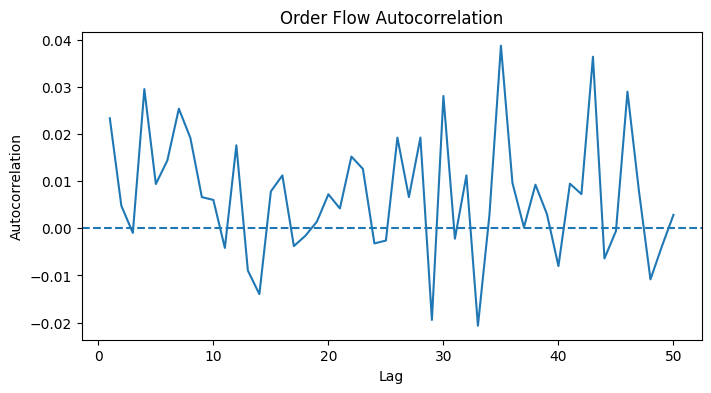

In [21]:
plt.figure(figsize=(8,4))

plt.plot(range(1, max_lag+1), autocorr)

plt.axhline(0, linestyle="--")

plt.title("Order Flow Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.show()

## Interpretation of Order Flow Autocorrelation

Biểu đồ trên thể hiện **autocorrelation của trade signs**
ở các lag khác nhau.

### Observations

Từ biểu đồ có thể quan sát:

- Autocorrelation dao động quanh **0**.
- Không có xu hướng giảm dần theo lag.
- Các giá trị dương và âm xuất hiện xen kẽ.

Điều này cho thấy **trade direction gần như độc lập theo thời gian**.

### Interpretation

Kết quả này phù hợp với mô hình **RandomOrderFlow**,
trong đó:

- buy và sell xảy ra ngẫu nhiên
- mỗi giao dịch không phụ thuộc giao dịch trước đó

Do đó ta kỳ vọng:

$$
\rho_k \approx 0
$$

đối với mọi lag.

Những dao động nhỏ quanh 0 chỉ là **sampling noise**
do số lượng mẫu hữu hạn.

### Comparison with Real Markets

Trong dữ liệu thị trường thực,
biểu đồ autocorrelation của trade signs thường rất khác.

Ta thường quan sát:

- autocorrelation dương ở nhiều lag
- giá trị giảm dần theo lag

Cấu trúc này được gọi là **long memory in order flow**.

Nguyên nhân chính là **meta-order splitting**,
khi các nhà đầu tư lớn chia nhỏ giao dịch lớn
thành nhiều lệnh nhỏ thực hiện liên tiếp.

Phần tiếp theo của notebook sẽ mô phỏng
**persistent order flow** để tái tạo hiện tượng này.

## Persistent Order Flow

Để mô phỏng hiện tượng này,
ta sử dụng mô hình **PersistentOrderFlow**.

Trong mô hình này,
mỗi giao dịch có xác suất cao lặp lại cùng phía
với giao dịch trước đó.

Điều này tạo ra **long memory in order signs**.

In [6]:
orderbook = OrderBook()

liquidity = LiquidityModel()

market_maker = MarketMaker()

order_flow = PersistentOrderFlow(persistence=0.8)

sim = MarketSimulation(
    orderbook,
    liquidity,
    market_maker,
    order_flow,
)

In [7]:
result = sim.run(steps=5000)

prices2 = result["prices"]
trades2 = result["trades"]

In [8]:
order_flow_autocorrelation(trades2)

np.float64(0.6206953379895025)

## Interpretation of Persistent Order Flow

Kết quả từ simulation:
$$
order flow autocorrelation ≈ 0.62
$$


Giá trị này lớn hơn nhiều so với trường hợp **random order flow**.

### Observations

Autocorrelation dương lớn cho thấy:

- buy orders có xu hướng được theo sau bởi buy orders
- sell orders có xu hướng được theo sau bởi sell orders

Nói cách khác, direction của giao dịch **không còn độc lập theo thời gian**.

### Interpretation

Trong simulation này,
order flow được tạo bởi mô hình **PersistentOrderFlow**.

Mô hình này giả định rằng
mỗi giao dịch có xác suất cao lặp lại cùng direction
với giao dịch trước đó.

Cơ chế này tạo ra **sign autocorrelation**:

$$
Corr(s_t, s_{t-1}) > 0
$$

trong đó $s_t$ là trade sign.

### Connection to Real Markets

Trong dữ liệu thị trường thực,
trade signs thường có autocorrelation dương
trong nhiều lag.

Hiện tượng này được gọi là:

**order flow persistence**

Nguyên nhân chính là các **meta orders**.

Khi một nhà đầu tư lớn muốn giao dịch khối lượng lớn,
họ thường chia giao dịch thành nhiều lệnh nhỏ
được thực hiện trong thời gian dài.

Điều này tạo ra chuỗi giao dịch cùng direction:

buy → buy → buy → buy
sell → sell → sell → sell

### Implication

Order flow persistence là một trong những
stylized facts quan trọng của market microstructure.

Tuy nhiên,
một câu hỏi thú vị xuất hiện:

Nếu order flow có autocorrelation dương,
tại sao return của giá lại gần như **không có autocorrelation**?

Câu hỏi này sẽ được giải thích trong notebook tiếp theo,
khi chúng ta nghiên cứu vai trò của **liquidity và market makers**.

## Interpretation of Persistent Order Flow

Kết quả từ simulation:
## Meta Orders

Trong thị trường thực,
nhiều giao dịch lớn được chia nhỏ
để giảm price impact.

Quá trình này tạo ra **meta orders**:

một chuỗi dài các giao dịch cùng phía.

Ví dụ:

buy → buy → buy → buy → buy

Điều này là nguồn gốc chính của
**order flow persistence**.

In [9]:
orderbook = OrderBook()

liquidity = LiquidityModel()

market_maker = MarketMaker()

order_flow = MetaOrderFlow()

sim = MarketSimulation(
    orderbook,
    liquidity,
    market_maker,
    order_flow,
)

In [10]:
result = sim.run(steps=5000)

prices3 = result["prices"]
trades3 = result["trades"]

In [11]:
order_flow_autocorrelation(trades3)

np.float64(0.5031425722576754)

## Interpretation of Persistent Order Flow

Kết quả từ simulation:
$$
order flow autocorrelation ≈ 0.50
$$

Giá trị này cho thấy **trade signs có mức persistence cao**.

### Observations

Autocorrelation dương lớn cho thấy:

- nhiều giao dịch liên tiếp có cùng direction
- buy trades thường được theo sau bởi buy trades
- sell trades thường được theo sau bởi sell trades

Chuỗi trade signs vì vậy xuất hiện các đoạn như:

buy → buy → buy → buy
sell → sell → sell → sell

### Meta Orders

Trong mô hình hiện tại,
order flow được sinh bởi **MetaOrderFlow**.

Mô hình này mô phỏng hành vi phổ biến trong thị trường thực:

một nhà đầu tư lớn muốn giao dịch khối lượng lớn,
nhưng không thể thực hiện toàn bộ giao dịch cùng lúc
vì price impact sẽ quá lớn.

Do đó giao dịch được chia thành nhiều **child orders** nhỏ.

Ví dụ:

$$
Q = q_1 + q_2 + q_3 + \dots + q_n
$$

trong đó:

- $Q$ là meta-order lớn
- $q_i$ là các giao dịch nhỏ thực hiện theo thời gian

### Consequence

Meta-order splitting tạo ra:

- **order flow persistence**
- chuỗi dài các giao dịch cùng direction
- autocorrelation dương trong trade signs

Hiện tượng này được quan sát rộng rãi
trong dữ liệu thị trường tài chính.

### Implication

Meta-orders được xem là nguồn gốc chính của:

- **long memory in order flow**
- **large price impact events**
- **liquidity pressure**

Các notebook tiếp theo sẽ nghiên cứu
cách thị trường hấp thụ những meta-orders này
thông qua **liquidity và market making**.

## Summary

Trong notebook này chúng ta đã thấy rằng
price dynamics trong thị trường được tạo ra bởi **order flow**.

Các kết quả chính:

- order flow tạo ra biến động giá
- signed order flow quyết định direction của price change
- persistence trong order flow có thể xuất hiện
  do meta-order splitting

Trong notebook tiếp theo,
chúng ta sẽ nghiên cứu vai trò của **liquidity và order book depth**
trong việc hấp thụ order flow và hình thành price impact.